In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define file path in Google Drive
file_path = "/content/drive/My Drive/cldbrst_dtst.csv"
df=pd.read_csv(file_path)

Mounted at /content/drive


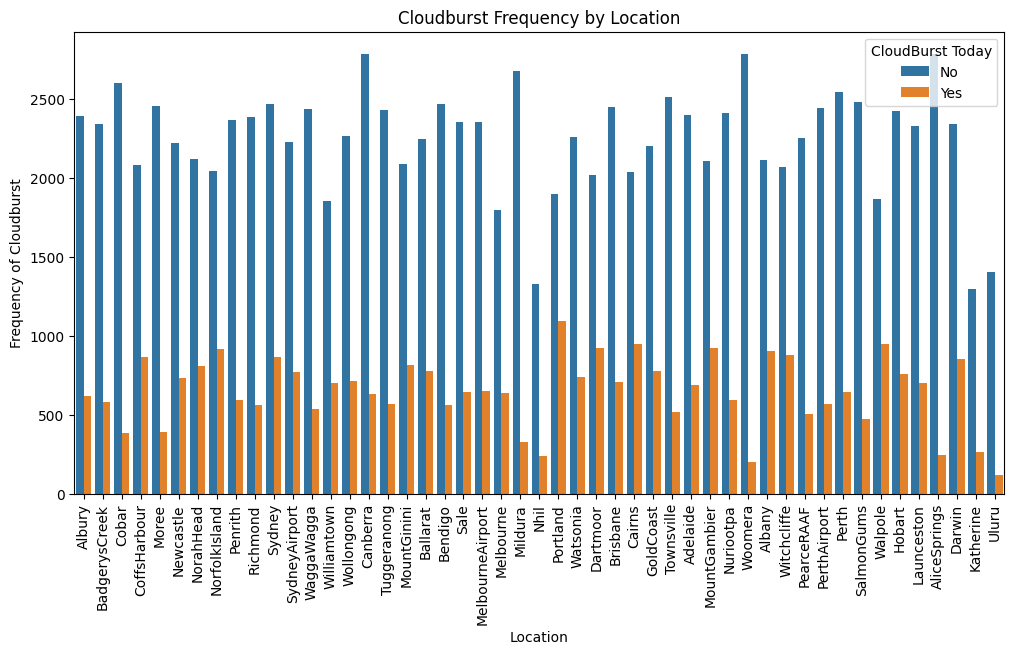

In [10]:
# Cloudburst vs. Location (assuming 'Location' is a categorical variable or label encoded)
plt.figure(figsize=(12, 6))
sns.countplot(x=df['Location'], hue=df['CloudBurst Today'])
plt.title('Cloudburst Frequency by Location')
plt.xlabel('Location')
plt.ylabel('Frequency of Cloudburst')
plt.xticks(rotation=90)
plt.show()


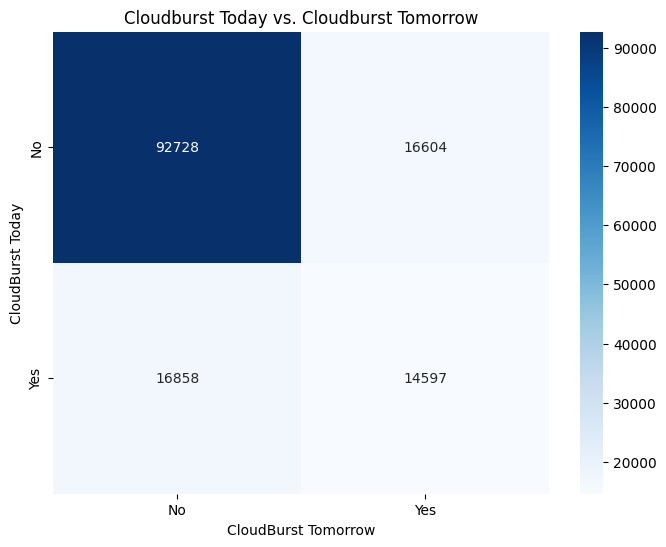

In [11]:
# Cloudburst Today vs. Cloudburst Tomorrow
plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df['CloudBurst Today'], df['CloudBurstTomorrow']), annot=True, cmap='Blues', fmt='d')
plt.title('Cloudburst Today vs. Cloudburst Tomorrow')
plt.xlabel('CloudBurst Tomorrow')
plt.ylabel('CloudBurst Today')
plt.show()


In [ ]:
df

,Date,Location,MinimumTemperature,MaximumTemperature,Rainfall,Evaporation,Sunshine,WindGustDirection,WindGustSpeed,WindDirection9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temperature9am,Temperature3pm,CloudBurst Today,CloudBurstTomorrow
0,01-12-2008,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,02-12-2008,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,03-12-2008,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,04-12-2008,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,05-12-2008,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,21-06-2017,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,22-06-2017,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,23-06-2017,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,24-06-2017,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


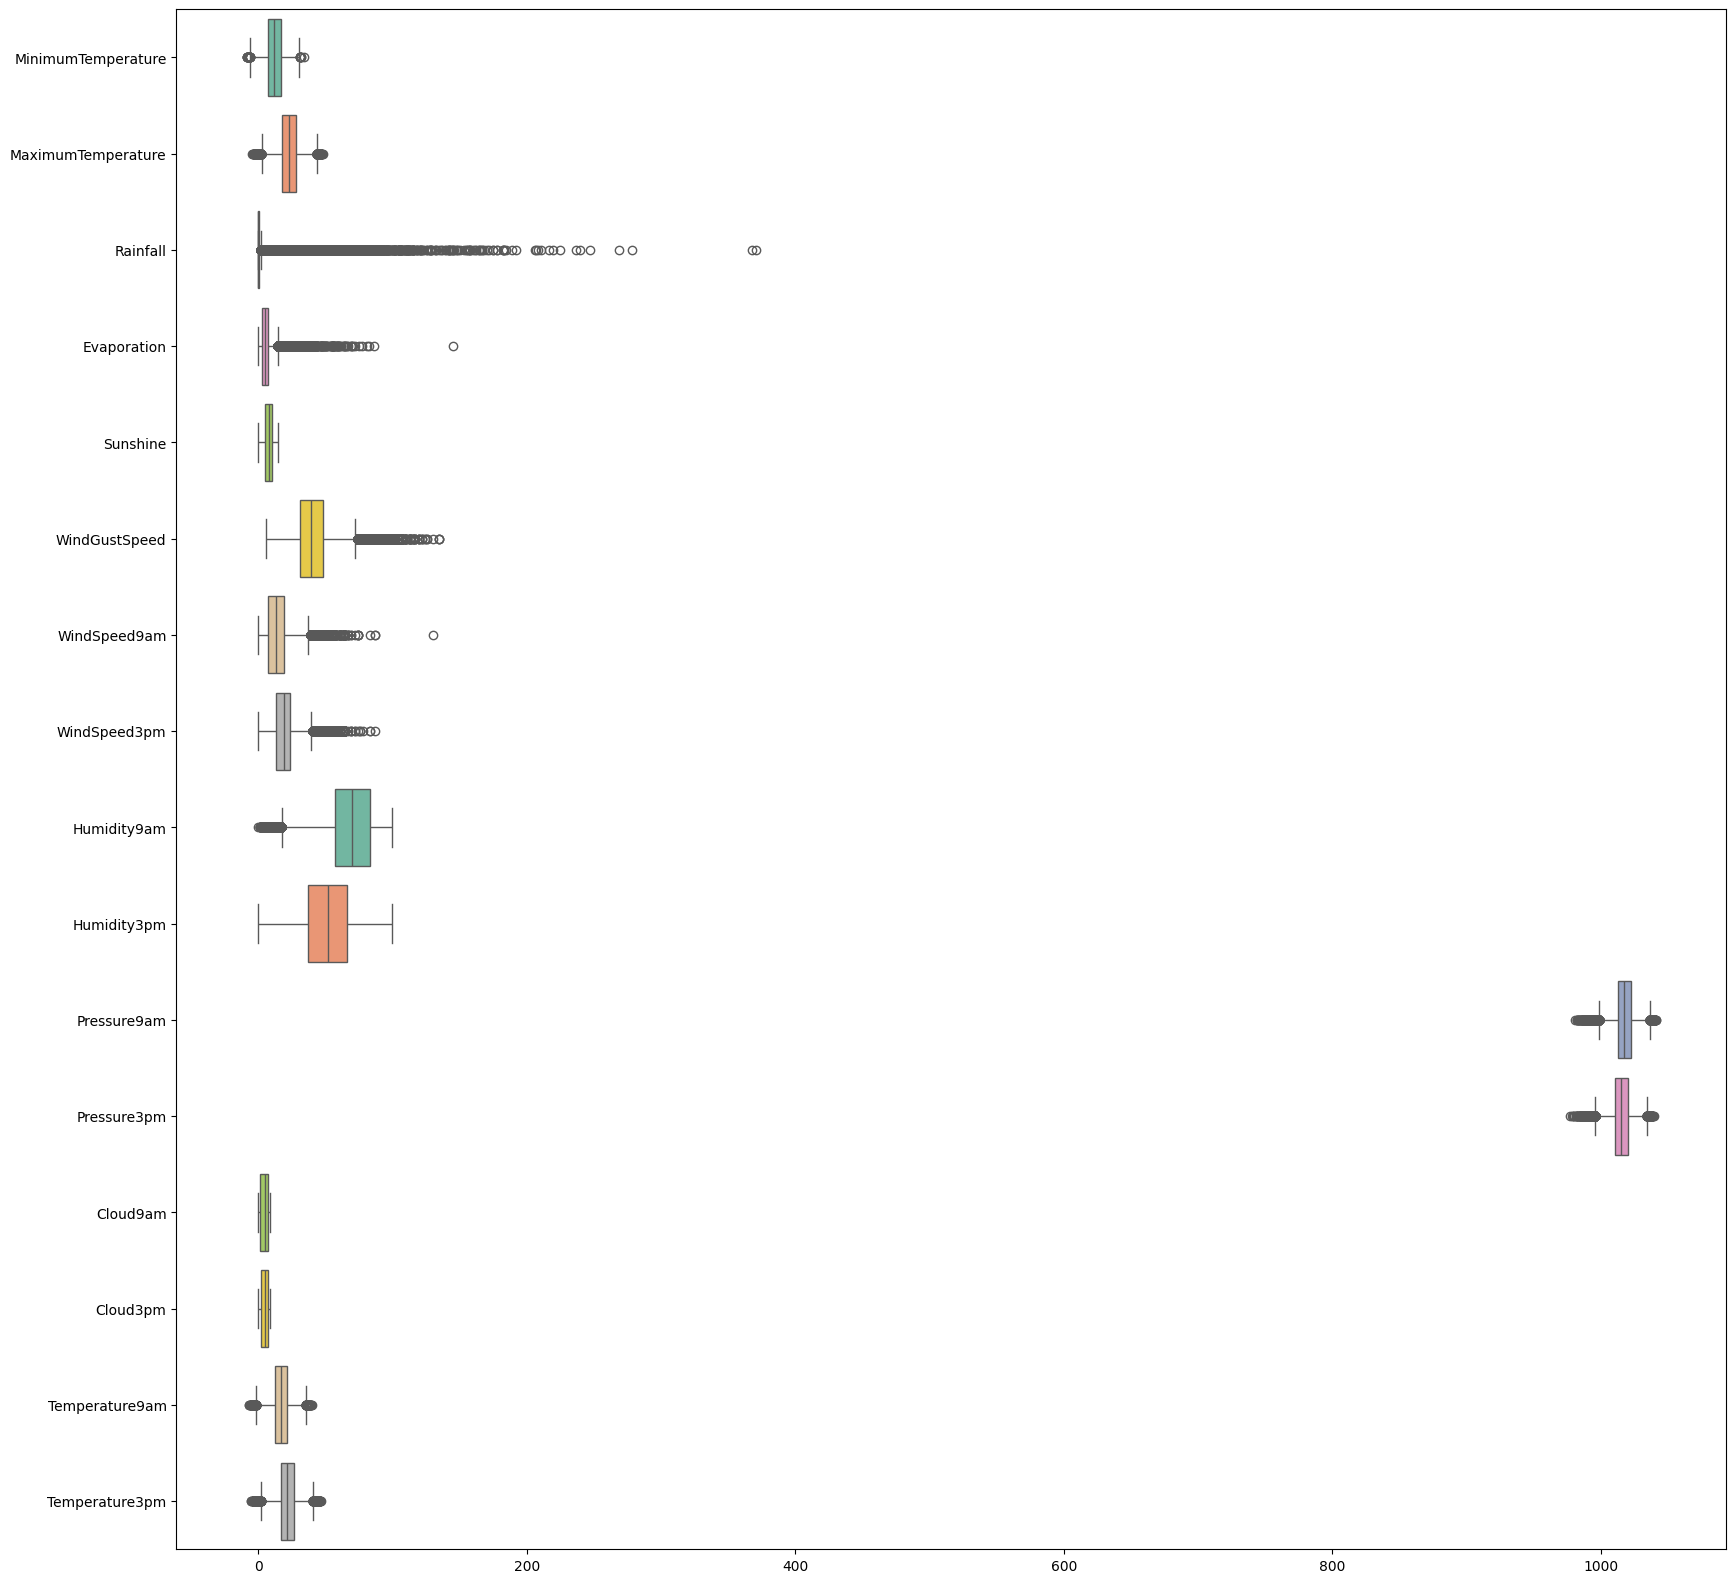

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 20))
sns.boxplot(data=df, orient='h', palette='Set2')
plt.show()
#boxplot


<ipython-input-4-71eb372578ad>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df["Rainfall"], orient='h', palette='Set2')


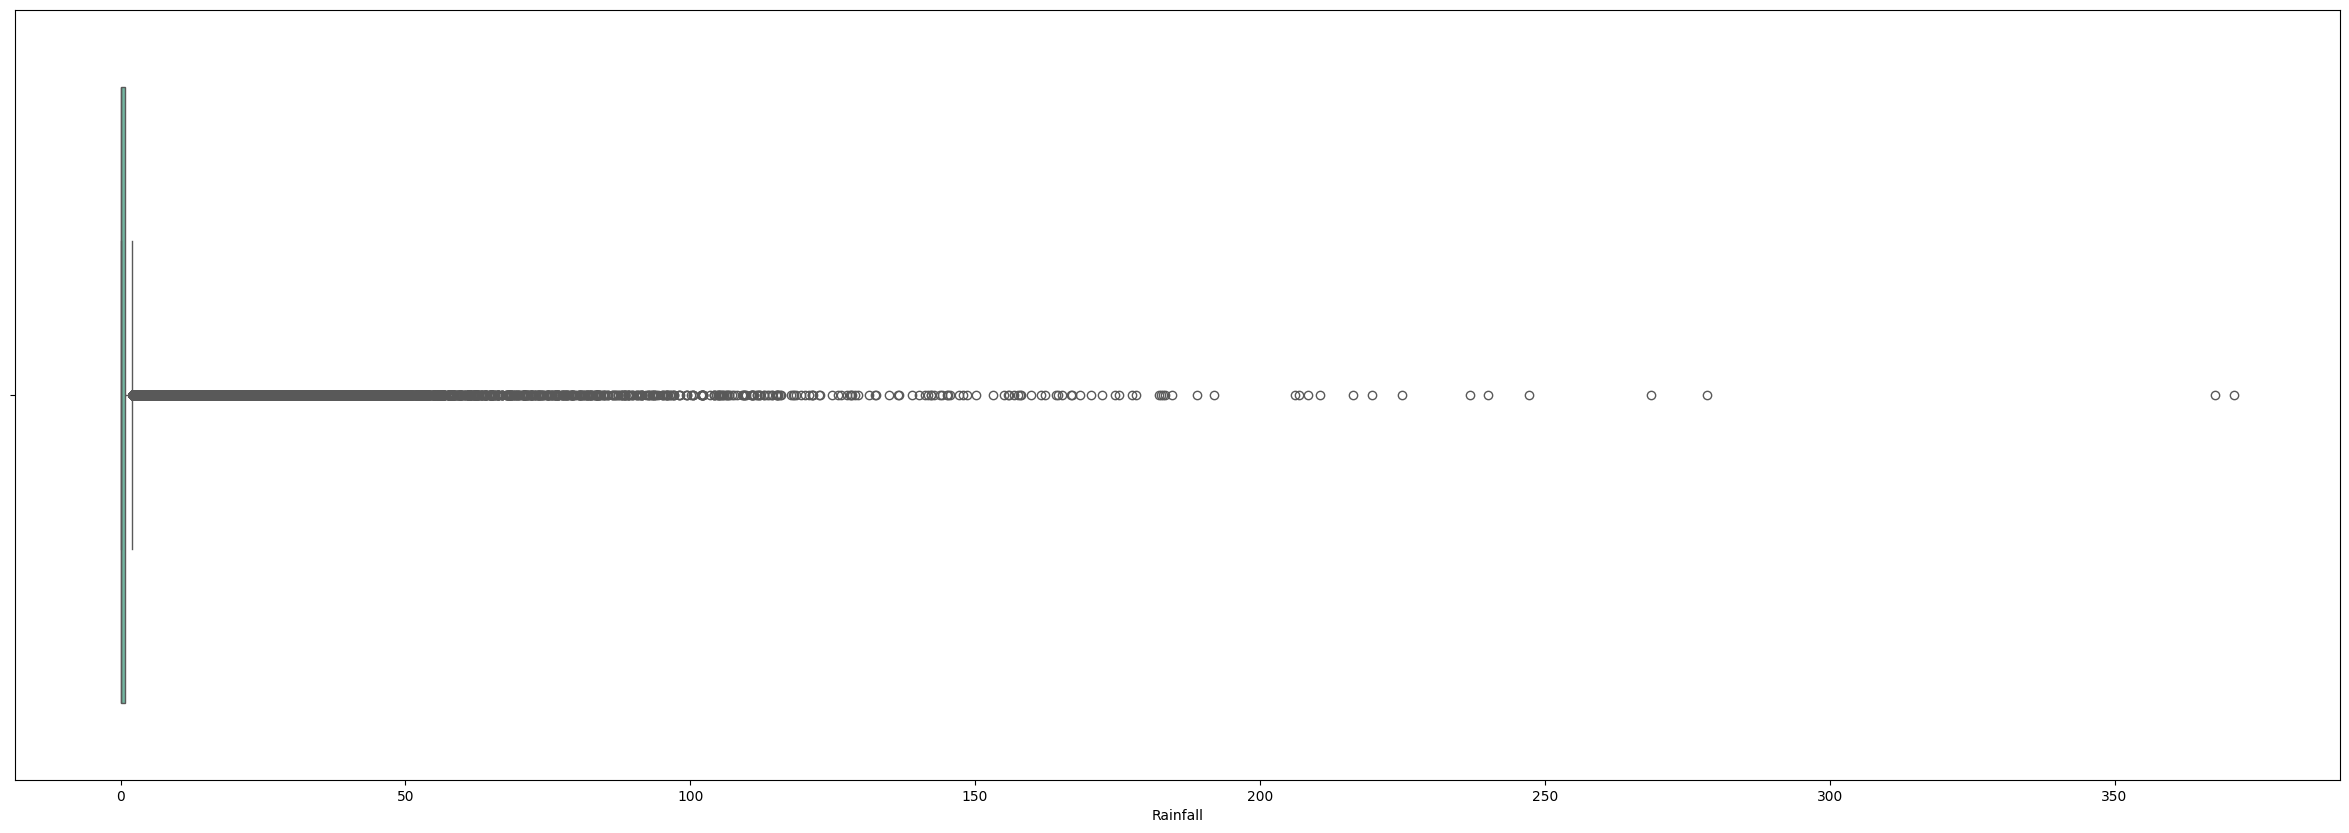

In [ ]:

plt.figure(figsize=(30, 10))
sns.boxplot(data=df["Rainfall"], orient='h', palette='Set2')
plt.show()


In [ ]:
def cap_outliers(df):
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    return df
df = cap_outliers(df)



In [ ]:
def count_outliers(df):
    outlier_counts = {}
    for col in df.select_dtypes(include=['float64', 'int64']):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_counts[col] = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    return outlier_counts
outliers = count_outliers(df)
print("Outliers in each column:")
for col, count in outliers.items():
    print(f"{col}: {count} outliers")


Outliers in each column:
MinimumTemperature: 0 outliers
MaximumTemperature: 0 outliers
Rainfall: 0 outliers
Evaporation: 0 outliers
Sunshine: 0 outliers
WindGustSpeed: 0 outliers
WindSpeed9am: 0 outliers
WindSpeed3pm: 0 outliers
Humidity9am: 0 outliers
Humidity3pm: 0 outliers
Pressure9am: 0 outliers
Pressure3pm: 0 outliers
Cloud9am: 0 outliers
Cloud3pm: 0 outliers
Temperature9am: 0 outliers
Temperature3pm: 0 outliers


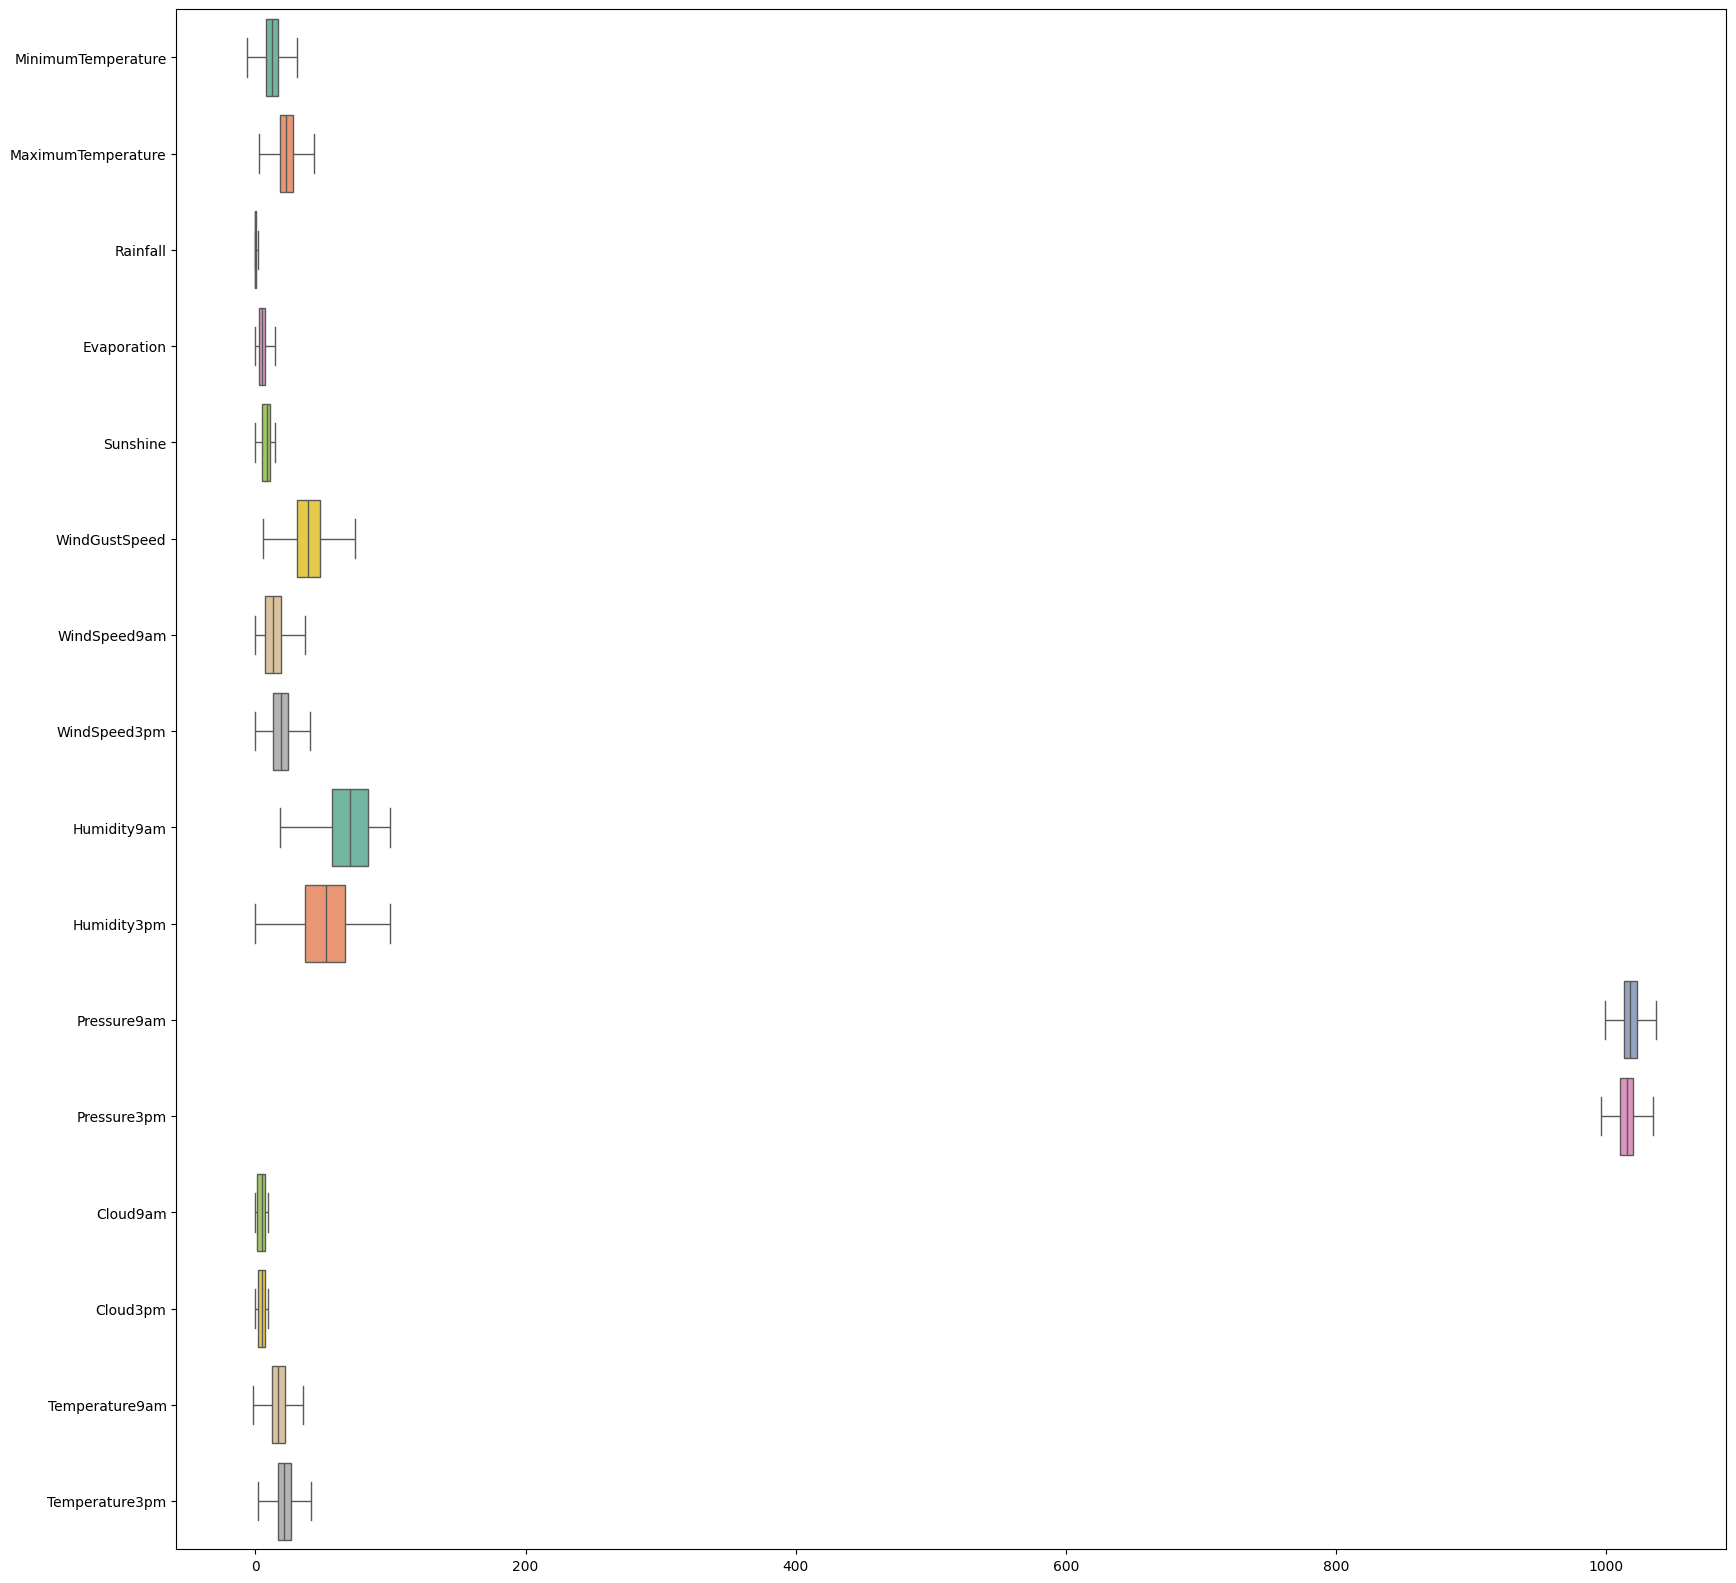

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 20))
sns.boxplot(data=df, orient='h', palette='Set2')
plt.show()


In [ ]:
df.isnull().sum()


,0
Date,0
Location,0
MinimumTemperature,1485
MaximumTemperature,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDirection,10326
WindGustSpeed,10263
WindDirection9am,10566


In [ ]:
from sklearn.impute import SimpleImputer
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
numerical_imputer = SimpleImputer(strategy='mean')
df[numerical_columns] = numerical_imputer.fit_transform(df[numerical_columns])
print(df.isnull().sum())

Date                      0
Location                  0
MinimumTemperature        0
MaximumTemperature        0
Rainfall                  0
Evaporation               0
Sunshine                  0
WindGustDirection     10326
WindGustSpeed             0
WindDirection9am      10566
WindDirection3pm       4228
WindSpeed9am              0
WindSpeed3pm              0
Humidity9am               0
Humidity3pm               0
Pressure9am               0
Pressure3pm               0
Cloud9am                  0
Cloud3pm                  0
Temperature9am            0
Temperature3pm            0
CloudBurst Today       3261
CloudBurstTomorrow     3267
dtype: int64


In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])
print(df.isnull().sum())

Date                  0
Location              0
MinimumTemperature    0
MaximumTemperature    0
Rainfall              0
Evaporation           0
Sunshine              0
WindGustDirection     0
WindGustSpeed         0
WindDirection9am      0
WindDirection3pm      0
WindSpeed9am          0
WindSpeed3pm          0
Humidity9am           0
Humidity3pm           0
Pressure9am           0
Pressure3pm           0
Cloud9am              0
Cloud3pm              0
Temperature9am        0
Temperature3pm        0
CloudBurst Today      0
CloudBurstTomorrow    0
dtype: int64


In [ ]:
#output_file_path = "/content/drive/My Drive/noutnull.csv"
#df.to_csv(output_file_path, index=False)
#print(f"Dataset saved as: {output_file_path}")

